In [155]:
# Process the calibration data from the downloaded files

import os
import zipfile
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

'''
index   parameter
2       gamma
3       kappa
4       eta1
5       sig
6       lam
7       mup
8       sigp
9       rsmax
10      alpha
11      alpha1
12      alpha2
13      betam1
14      n
15      kappa_k
'''

def get_info(test_dir):

    # (1) Unzip the results.zip file
    resultsFileDir = test_dir + '/results'
    resultsZip = test_dir + '/results.zip'

    if not os.path.exists(resultsFileDir):
        print('Results folder does not exist... Trying to unzip results.zip')
        if os.path.exists(resultsZip):
            print('Unzipping results.zip')
            with zipfile.ZipFile(resultsZip, 'r') as zip_ref:
                zip_ref.extractall(test_dir)
        else:
            print('results.zip file does not exist')
            check = 0

    # (2) Load the scInput file
    # Try to open the scInput.json file...
    try:
        scInputFile = test_dir + r'/results/templatedir/scInput.json'
        with open(scInputFile) as f:
            scInput = json.load(f)
        check = 1
    except Exception as e:
        print('Error trying to open scInput.json file... ', e)
        check = 0

    # (3) Check if UQ application is UCSD-UQ. If it's not, exit the function
    if check == 1:
        if scInput["Applications"]['UQ']['Application'] != 'UCSD-UQ':
            print(scInput["Applications"]['UQ'])
            print('Not a UCSD-UQ Calibration')
            return [], [], [], []
    
        else:
            try:
                # If it is a UCSD-UQ calibration, continue with the process...

                # (4) Unzip the templatedir.zip file
                templatedirDir = test_dir + '/templatedir'
                templatedirZip = test_dir + '/templatedir.zip'

                if not os.path.exists(templatedirDir):
                    print('Template folder does not exist... Trying to unzip templatedir.zip')
                    if os.path.exists(templatedirZip):
                        print('Unzipping templatedir.zip')
                        with zipfile.ZipFile(templatedirZip, 'r') as zip_ref:
                            zip_ref.extractall(test_dir)
                    else:
                        print('templatedir.zip file does not exist')
                
                # (5) Load the dakotaTab.out file
                dakotaTabFile = test_dir + r'/results/dakotaTab.out'
                results = pd.read_csv(dakotaTabFile, sep='\s+')

                # (6) Load the test file
                testFile = templatedirDir + r'/test_file.json'
                with open(testFile) as f:
                    test_file = json.load(f)

                # Section 3: Get the info
                # Split the test_dir by the backslash
                test_dir_split = test_dir.split('\\')
                # Get the last part of the split
                test_dir_name = test_dir_split[-1]

                UniqueId = scInput["Applications"]["FEM"]["ApplicationData"]["MS_Path"][-3:]
                info = {'UniqueId': UniqueId,
                        'Name': test_file['Name'],
                        'Location': test_dir_name
                        }

                return info, scInput, test_file, results
            except Exception as e:
                print('Error trying to get calibration data... ', e)
                return [], [], [], []
    else:
        return [], [], [], []

def plot_hysteresis(test_file, results):

    plt.figure()
    for ii in range(0, 200):
        plt.plot(test_file['cal_data']['disp'], results.iloc[ii, 17::], 'r:.', linewidth=0.1, alpha=0.2)

    plt.plot(test_file['cal_data']['disp'], test_file['cal_data']['force'], 'b:.', alpha=0.5)
    plt.show()


def get_residual_info(test_file, results):

    # Get statistics on the residuals
    residuals = np.array(results.iloc[:, 17::]) - np.array(test_file['cal_data']['force'])
    residuals = np.abs(residuals / np.max(np.array(test_file['cal_data']['force'])))

    # get mean residual about axis 0
    residuals = np.mean(residuals, axis=1)

    # Mean, std, max, min of mean of residuals
    mean = np.mean(residuals)
    median = np.median(residuals)
    std = np.std(residuals)
    max = np.max(residuals)
    min = np.min(residuals)

    residual_statistics = {'mean': mean, 'median': median, 'std': std, 'max': max, 'min': min}
    
    # Get the best fit index
    best_fit_index = np.argmin(residuals)

    # Get parameters for best fit
    best_fit_parameters = results.iloc[best_fit_index, 2:16].values
    
    return residual_statistics, best_fit_parameters


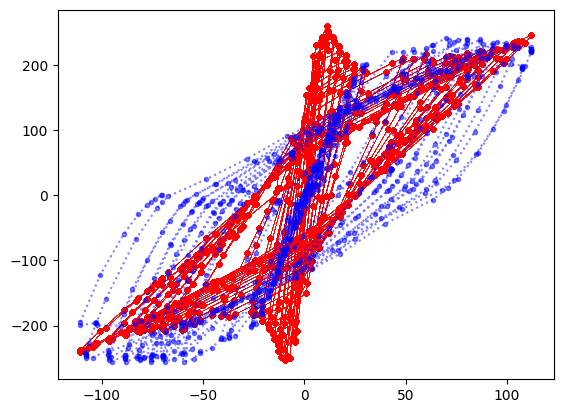

[1.83947591 1.0459381  0.74817855 0.86310192 0.50107327 3.66402238
 1.91142821 0.18778852 0.02928681 1.82364105 0.5936857  0.01378885
 7.29790548 0.83826212]
{'UniqueId': '196', 'Name': 'Aboutaha and Machado 1999, ORC1', 'Location': '011804ba-2a57-40df-9e85-9dd21edc7957-007', 'res_mean': 0.1977560378237073, 'res_median': 0.1977560378237073, 'res_std': 0.0, 'res_max': 0.1977560378237073, 'res_min': 0.1977560378237073, 'gamma': 1.8394759146681456, 'kappa': 1.0459380963863194, 'eta1': 0.7481785455491181, 'sig': 0.8631019228573644, 'lam': 0.501073273001298, 'mup': 3.664022377491615, 'sigp': 1.9114282079178075, 'rsmax': 0.1877885168650077, 'alpha': 0.0292868129229642, 'alpha1': 1.8236410524623523, 'alpha2': 0.5936857037331937, 'betam1': 0.0137888508683379, 'n': 7.297905484921455, 'kappa_k': 0.8382621193514618}
UniqueId already exists... 


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# The directory where the files are stored
remoteWorkDir = r'D:\tacc scratch'
month = '25_03'
day = '13'

allJobs = os.listdir(os.path.join(remoteWorkDir, month, day))

for ii in range(0, len(allJobs)):
    info, scInput, test_file, results = get_info(os.path.join(remoteWorkDir, month, day, allJobs[ii]))
    try:
        plot_hysteresis(test_file, results)
        res_stats, best_fit = get_residual_info(test_file, results)
    except Exception as e:
        print('Error trying to plot hysteresis... ', e)
        continue
    
    # Add fit information to the info dictionary
    info['res_mean'] = res_stats['mean']
    info['res_median'] = res_stats['median']
    info['res_std'] = res_stats['std']
    info['res_max'] = res_stats['max']
    info['res_min'] = res_stats['min']
    print(best_fit)
    
    (info['gamma'], info['kappa'], info['eta1'], info['sig'], info['lam'], 
     info['mup'], info['sigp'], info['rsmax'], info['alpha'], info['alpha1'], 
     info['alpha2'], info['betam1'], info['n'], info['kappa_k']) = best_fit.tolist()

    #
    print(info)

    # Save the info dictionary to a csv file

    # Open the calibration_info.csv file and check if the UniqueId exists
    if os.path.exists('calibration_info.csv'):
        calibration_info = pd.read_csv('calibration_info.csv')
        if int(info['UniqueId']) in calibration_info['UniqueId'].values:
            print('UniqueId already exists... ')
            # Check if the existing Location is the same as the new one
            existing_location = calibration_info.loc[calibration_info['UniqueId'] == int(info['UniqueId']), 'Location'].values[0]
            if existing_location == info['Location']:
                print('Location is the same... Updating the info')
                # Replace the row with the new info
                calibration_info = calibration_info.replace(info['UniqueId'], info)
                calibration_info.to_csv('calibration_info.csv', index=False)
            else:
                print('Location is different... Updating the info')
                # Pause and ask what to do
                print('Existing Location: ', existing_location)
                print('New Location: ', info['Location'])
                print('What do you want to do?')
                print('1. Update the info')
                print('2. Skip the info')
                choice = input('Enter your choice: ')
                if choice == '1':
                    # Replace the row with the new info
                    calibration_info = calibration_info.replace(info['UniqueId'], info)
                    calibration_info.to_csv('calibration_info.csv', index=False)
                else:
                    print('Skipping the info')
                    continue
            
        else:
            # Append the info to the csv file
            print('UniqueId does not exist... Adding new info')
            info_df = pd.DataFrame(info, index=[0])
            info_df.to_csv('calibration_info.csv', mode='a', header=False, index=False)
    else:
        # Create the csv file and add the info as the first row
        print('calibration_info.csv not found... Creating a new one')
        calibration_info = pd.DataFrame(columns=info.keys())
        calibration_info.to_csv('calibration_info.csv', index=False)




In [162]:
calibration_info['UniqueId'].values

array([196, 148, 387,   1,  83, 246, 303, 334, 298,   6, 118, 104, 220,
       318, 289, 246, 119, 288, 196, 172,  21, 118, 329,  95, 363, 102,
       266, 226, 270, 329, 174, 314, 102, 355, 379, 298, 365, 295,  60,
       144,  99,  17,  27, 114,  10, 293, 359, 375,  26, 285, 381, 294,
       345, 152,  76,  11,  56, 401, 304,  10, 312, 113, 179, 353, 386,
       354, 328, 338, 277,  51, 373, 142, 113, 271, 416, 163, 304,  66,
       362,  16, 334, 291, 104,  47, 356, 345,  76, 315,   6, 270, 196,
       148, 387,   1,  83, 246, 303, 334, 298,   6, 118, 104, 220, 318,
       289, 246, 119, 288, 196, 172,  21, 118, 329,  95, 363, 102, 266,
       226, 270, 329, 174, 314, 102, 355, 379, 298, 365, 295,  60, 144,
        99,  17,  27, 114,  10, 293, 359, 375,  26, 285, 381, 294, 345,
       152,  76,  11,  56, 401, 304,  10, 312, 113, 179, 353, 386, 354,
       328, 338, 277,  51, 373, 142, 113, 271, 416, 163, 304,  66, 362,
        16, 334, 291, 104,  47, 356, 345,  76, 315,   6], dtype=

In [163]:
info['UniqueId']

'270'